In [1]:
import os
os.listdir("../data")

['ai4i2020.csv', 'ai4i2020_cleaned.csv', 'ai4i2020_features.csv']

In [2]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(df.shape)
df.info()

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [6]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [7]:
df.groupby("Machine failure")[["Air temperature [K]", "Torque [Nm]", "Tool wear [min]"]].mean()

,Air temperature [K],Torque [Nm],Tool wear [min]
Machine failure,,,
0,299.973999,39.629655,106.693717
1,300.886431,50.168142,143.781711


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Power [W]"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]
df.sort_values("Power [W]", ascending=False).head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Power [W]
9084,9085,L56264,L,297.2,307.9,1326,75.4,172,1,0,0,1,1,0,99980.4
8307,8308,M23167,M,298.7,310.1,1402,69.7,64,1,0,0,1,0,0,97719.4
6525,6526,L53705,L,301.1,310.4,1312,73.6,49,1,0,0,1,0,0,96563.2
3000,3001,H32414,H,300.5,309.8,1324,72.8,159,1,0,0,1,0,0,96387.2
8582,8583,M23442,M,297.5,308.1,1334,72.0,151,1,0,0,1,0,0,96048.0


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

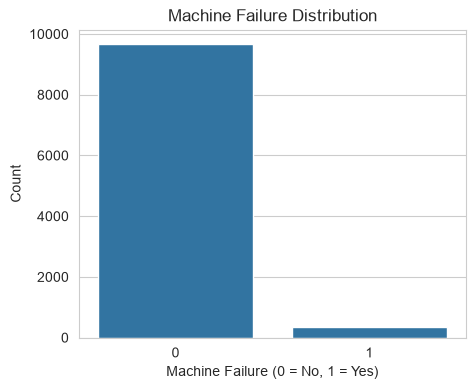

In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Machine failure")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [12]:
   import pandas as pd
   df = pd.read_csv("../data/ai4i2020.csv")
   df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


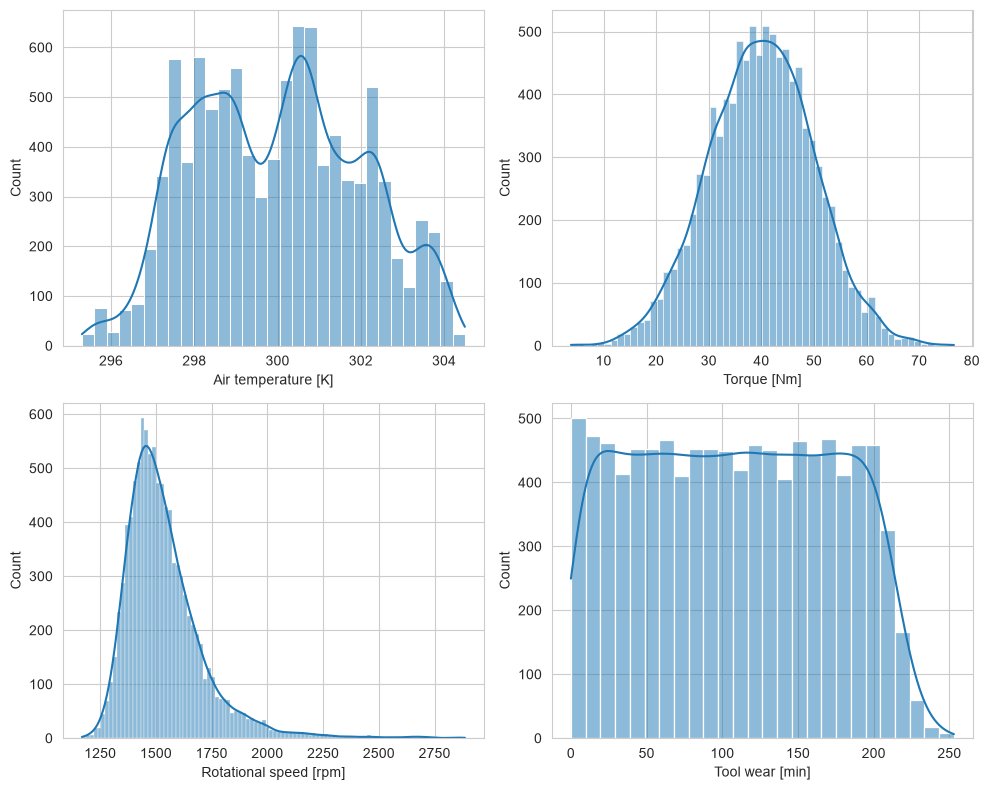

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(df["Air temperature [K]"], kde=True, ax=axes[0, 0])
sns.histplot(df["Torque [Nm]"], kde=True, ax=axes[0, 1])
sns.histplot(df["Rotational speed [rpm]"], kde=True, ax=axes[1, 0])
sns.histplot(df["Tool wear [min]"], kde=True, ax=axes[1, 1])

plt.tight_layout()
plt.show()

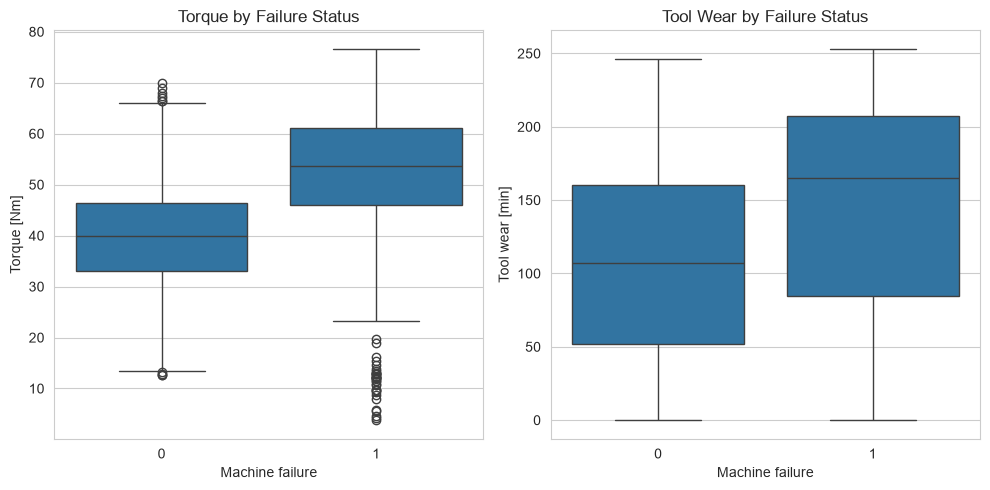

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(data=df, x="Machine failure", y="Torque [Nm]", ax=axes[0])
axes[0].set_title("Torque by Failure Status")

sns.boxplot(data=df, x="Machine failure", y="Tool wear [min]", ax=axes[1])
axes[1].set_title("Tool Wear by Failure Status")

plt.tight_layout()
plt.show()

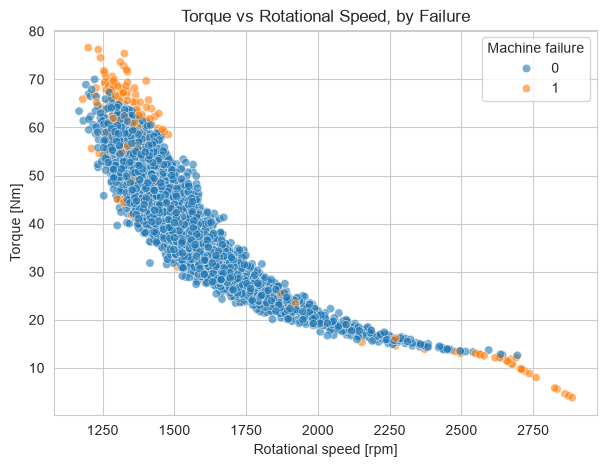

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Rotational speed [rpm]", y="Torque [Nm]", hue="Machine failure", alpha=0.6)
plt.title("Torque vs Rotational Speed, by Failure")
plt.show()

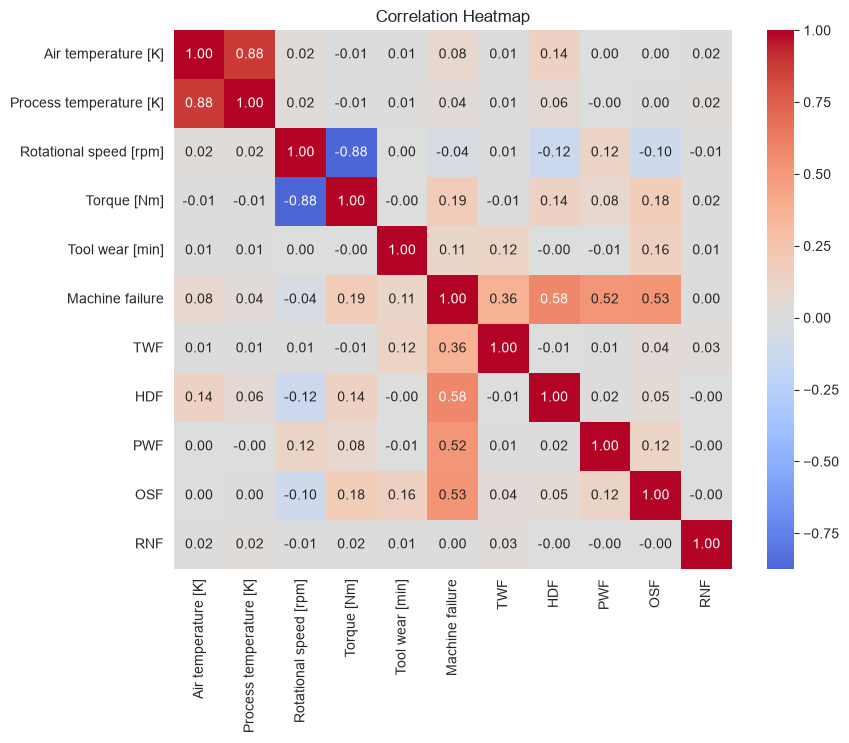

In [16]:
plt.figure(figsize=(9, 7))
numeric_df = df.drop(columns=["UDI"])
correlation_matrix = numeric_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Columns we exclude from modeling, and why
id_columns = ["UDI", "Product ID"]                          # identifiers, not generalizable features
leakage_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]        # components of the target itself

df_clean = df.drop(columns=id_columns + leakage_columns)
df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [18]:
df_clean.to_csv("../data/ai4i2020_cleaned.csv", index=False)

In [19]:
df_clean.to_csv("../data/ai4i2020_cleaned.csv", index=False)

In [20]:
df_clean["Power [W]"] = df_clean["Torque [Nm]"] * df_clean["Rotational speed [rpm]"]

In [21]:
df_clean["Temp difference [K]"] = df_clean["Process temperature [K]"] - df_clean["Air temperature [K]"]

In [22]:
df_clean["Strain [Nm·min]"] = df_clean["Tool wear [min]"] * df_clean["Torque [Nm]"]

In [23]:
df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power [W],Temp difference [K],Strain [Nm·min]
0,M,298.1,308.6,1551,42.8,0,0,66382.8,10.5,0.0
1,L,298.2,308.7,1408,46.3,3,0,65190.4,10.5,138.9
2,L,298.1,308.5,1498,49.4,5,0,74001.2,10.4,247.0
3,L,298.2,308.6,1433,39.5,7,0,56603.5,10.4,276.5
4,L,298.2,308.7,1408,40.0,9,0,56320.0,10.5,360.0


In [24]:
df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power [W],Temp difference [K],Strain [Nm·min]
0,M,298.1,308.6,1551,42.8,0,0,66382.8,10.5,0.0
1,L,298.2,308.7,1408,46.3,3,0,65190.4,10.5,138.9
2,L,298.1,308.5,1498,49.4,5,0,74001.2,10.4,247.0
3,L,298.2,308.6,1433,39.5,7,0,56603.5,10.4,276.5
4,L,298.2,308.7,1408,40.0,9,0,56320.0,10.5,360.0


In [25]:
df_clean.to_csv("../data/ai4i2020_features.csv", index=False)

In [26]:
df_encoded = pd.get_dummies(df_clean, columns=["Type"], drop_first=True)
df_encoded.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power [W],Temp difference [K],Strain [Nm·min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,66382.8,10.5,0.0,False,True
1,298.2,308.7,1408,46.3,3,0,65190.4,10.5,138.9,True,False
2,298.1,308.5,1498,49.4,5,0,74001.2,10.4,247.0,True,False
3,298.2,308.6,1433,39.5,7,0,56603.5,10.4,276.5,True,False
4,298.2,308.7,1408,40.0,9,0,56320.0,10.5,360.0,True,False


In [27]:
X = df_encoded.drop(columns=["Machine failure"])
y = df_encoded["Machine failure"]

print(X.columns.tolist())
print(y.name)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power [W]', 'Temp difference [K]', 'Strain [Nm·min]', 'Type_L', 'Type_M']
Machine failure


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held back for testing
    random_state=42,    # makes the split reproducible
    stratify=y          # preserve the failure/no-failure ratio in both sets
)

In [29]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)


In [30]:
print("Train failure rate:", y_train.mean())
print("Test failure rate:", y_test.mean())

Train failure rate: 0.033875
Test failure rate: 0.034


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [32]:
predictions = model.predict(X_test)
print(predictions[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [33]:
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[4.15990176e-01 5.84009824e-01]
 [9.82598078e-01 1.74019218e-02]
 [9.66082352e-01 3.39176485e-02]
 [9.99380877e-01 6.19123186e-04]
 [7.98233225e-01 2.01766775e-01]]


In [34]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9695


In [35]:
actual_failures = (y_test == 1).sum()
caught_failures = ((y_test == 1) & (predictions == 1)).sum()
print(f"Actual failures in test set: {actual_failures}")
print(f"Correctly predicted as failures: {caught_failures}")

Actual failures in test set: 68
Correctly predicted as failures: 14


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1925    7]
 [  54   14]]


In [37]:
print(classification_report(y_test, predictions, target_names=["No Failure", "Failure"]))

              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.67      0.21      0.31        68

    accuracy                           0.97      2000
   macro avg       0.82      0.60      0.65      2000
weighted avg       0.96      0.97      0.96      2000



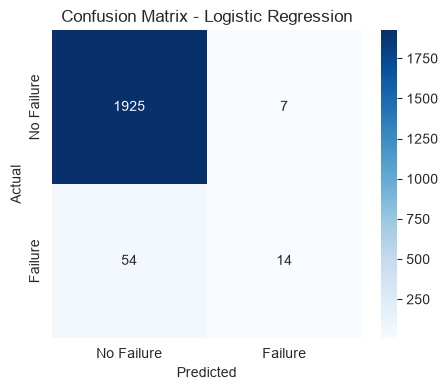

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced.fit(X_train, y_train)

predictions_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, predictions_balanced, target_names=["No Failure", "Failure"]))
print(confusion_matrix(y_test, predictions_balanced))

              precision    recall  f1-score   support

  No Failure       1.00      0.86      0.92      1932
     Failure       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000

[[1654  278]
 [   8   60]]


In [40]:
probabilities_balanced = model_balanced.predict_proba(X_test)[:, 1]  # probability of failure
predictions_threshold = (probabilities_balanced >= 0.3).astype(int)

print(classification_report(y_test, predictions_threshold, target_names=["No Failure", "Failure"]))

              precision    recall  f1-score   support

  No Failure       1.00      0.73      0.85      1932
     Failure       0.11      0.94      0.20        68

    accuracy                           0.74      2000
   macro avg       0.55      0.84      0.52      2000
weighted avg       0.97      0.74      0.82      2000



In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_balanced, X, y, cv=5, scoring="recall")
print("Recall per fold:", scores)
print("Average recall:", scores.mean())

D:\resume-projects\machinemind\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\resume-projects\machinemind\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Recall per fold: [0.80597015 0.88235294 0.86764706 0.83823529 0.66176471]
Average recall: 0.8111940298507463


D:\resume-projects\machinemind\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
model_balanced_scaled = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced_scaled.fit(X_train_scaled, y_train)

predictions_scaled = model_balanced_scaled.predict(X_test_scaled)
print(classification_report(y_test, predictions_scaled, target_names=["No Failure", "Failure"]))
print(confusion_matrix(y_test, predictions_scaled))

              precision    recall  f1-score   support

  No Failure       1.00      0.86      0.92      1932
     Failure       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000

[[1658  274]
 [   8   60]]


In [44]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

scores_pipeline = cross_val_score(pipeline, X, y, cv=5, scoring="recall")
print("Recall per fold (with scaling):", scores_pipeline)
print("Average recall:", scores_pipeline.mean())

Recall per fold (with scaling): [0.73134328 0.88235294 0.88235294 0.83823529 0.61764706]
Average recall: 0.7903863037752414


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

final_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', ...,'Strain [Nm·min]','Type_L','Type_M']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [46]:
import joblib

joblib.dump(final_pipeline, "../models/machine_failure_model.pkl")

['../models/machine_failure_model.pkl']

In [47]:
feature_columns = list(X.columns)
joblib.dump(feature_columns, "../models/feature_columns.pkl")
print(feature_columns)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power [W]', 'Temp difference [K]', 'Strain [Nm·min]', 'Type_L', 'Type_M']
